The banks stocks that I considering for this EDA are:

- Banco do Brasil (BDORY)
- Banco Bradesco (BBD)
- Itaú Unibanco (ITUB)
- Santander (SAN)

They are all listed in the 'Brasil Bolsa Balcão' or 'B3' for short, which is the name of the major brazilian stock exchange

The reason for choosing these stocks is that I have relatives living in Brazil and I have familiarity with their domestic economic policies.

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import date, timedelta
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis


#### Data Preparation, Establishing the Timeframe, and Time-Series visualization

In [3]:
# Here we define a one year rollback period for the data
end_date = date.today().strftime("%Y-%m-%d")
start_date = (date.today() - timedelta(days=365)).strftime("%Y-%m-%d")

# By Assignign a list of stock tickers to download in a variable
# we make our job easier for the EDA and the plotting section of
# the project
tickers_bras = ['BDORY', 'BBD', 'ITUB', 'SAN']

data = yf.download(
                   tickers_bras, group_by='Ticker',
                   start=start_date,
                   end=end_date,
                   progress=False,
                   auto_adjust=True
                   )

# Reset index to bring Date into the columns for the melt function
stock_data = (
    data.stack(level=0, future_stack=True)
    .rename_axis(['Date', 'Ticker'])
    .reset_index(level=1)
    )


stock_data.reset_index(inplace=True)
stock_data.head()


Price,Date,Ticker,Open,High,Low,Close,Volume
0,2025-01-21,BDORY,4.123492,4.161850,4.056365,4.123492,370100
1,2025-01-21,SAN,4.867054,4.876887,4.847389,4.867054,3512700
2,2025-01-21,ITUB,4.199489,4.230596,4.183935,4.207266,19223045
3,2025-01-21,BBD,1.875378,1.904083,1.865810,1.875378,40744500
4,2025-01-22,BDORY,4.171439,4.305692,4.171439,4.248155,173300


#### Plotting the Adjusted Close prices over time

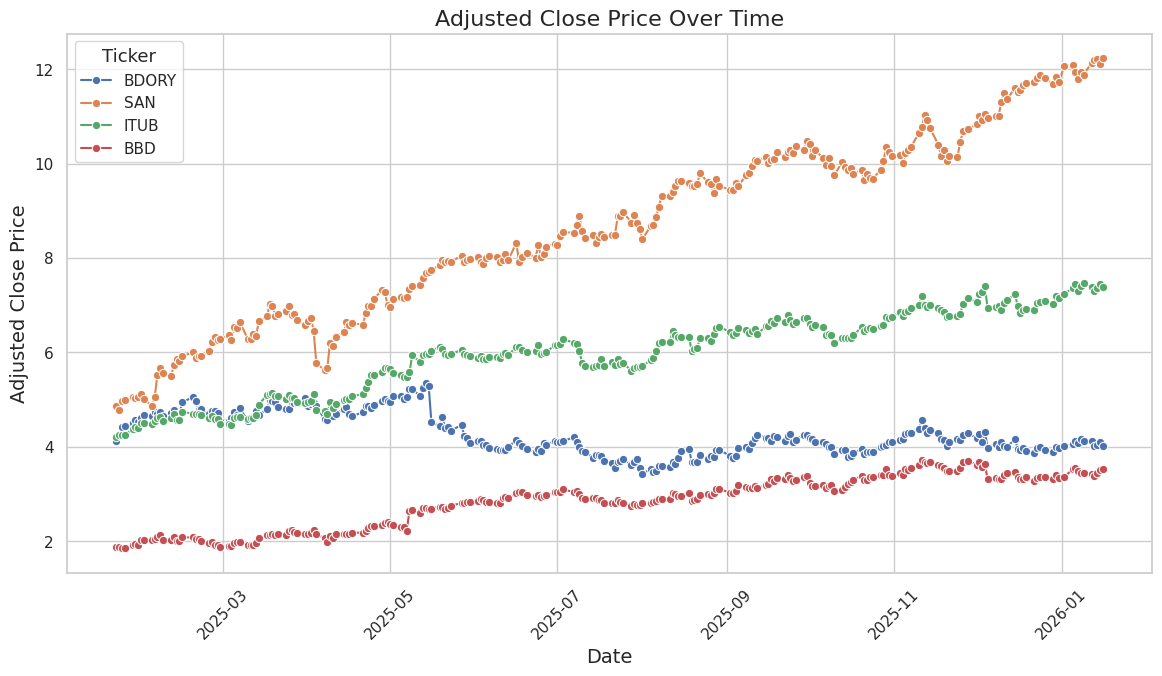

In [4]:
stock_data['Date'] = pd.to_datetime(stock_data['Date'])

stock_data.set_index('Date', inplace=True)
stock_data.reset_index(inplace=True)
plt.figure(figsize=(14, 7))
sns.set(style='whitegrid')

sns.lineplot(
    data=stock_data,
  x='Date',
  y='Close',
  hue='Ticker',
  marker='o')

plt.title('Adjusted Close Price Over Time', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Adjusted Close Price', fontsize=14)
plt.legend(title='Ticker', title_fontsize='13', fontsize='11')
plt.grid(True)

plt.xticks(rotation=45)

plt.show()

#### Plotting of 50 and 200 days Rolling Average

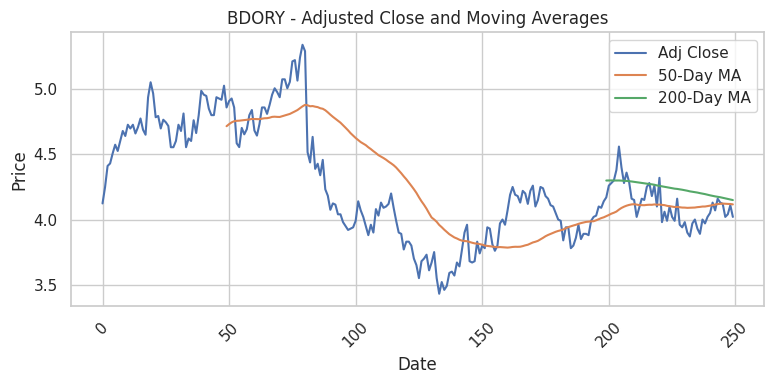

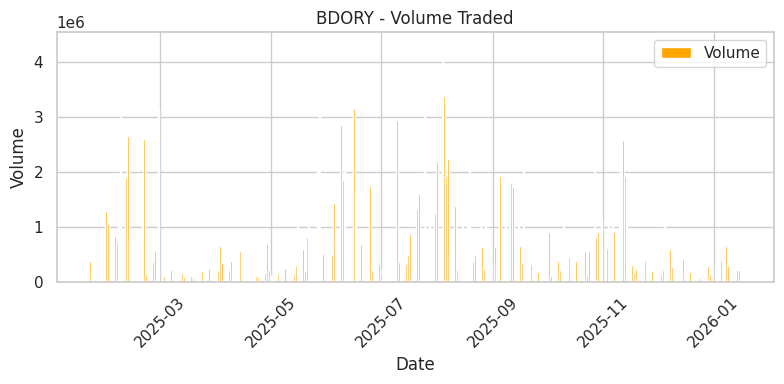

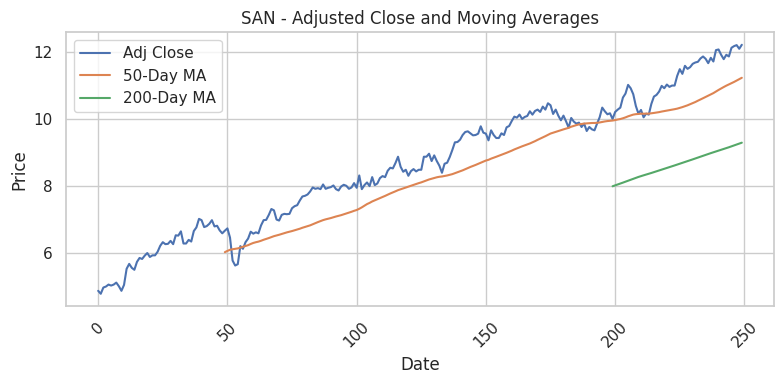

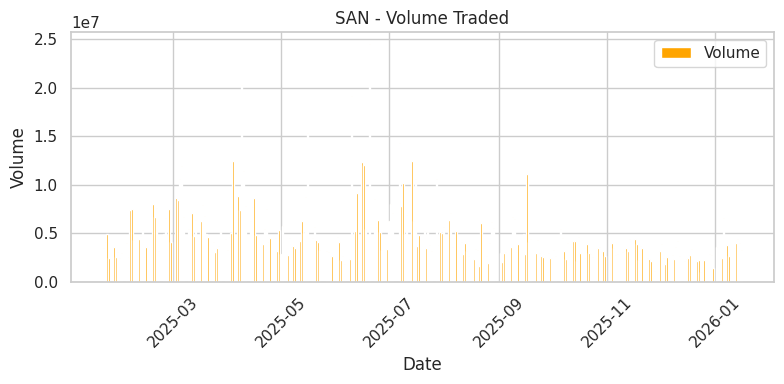

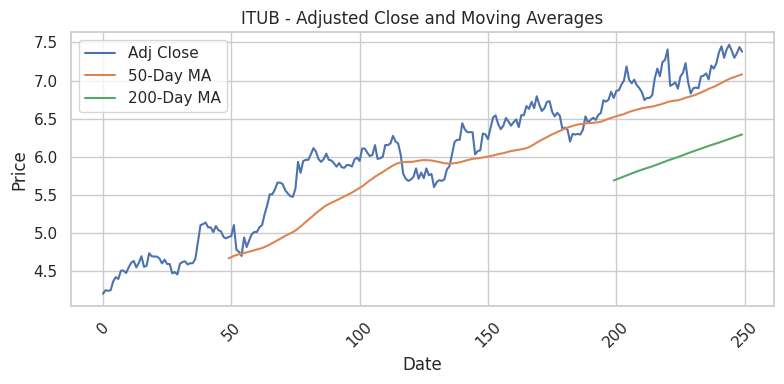

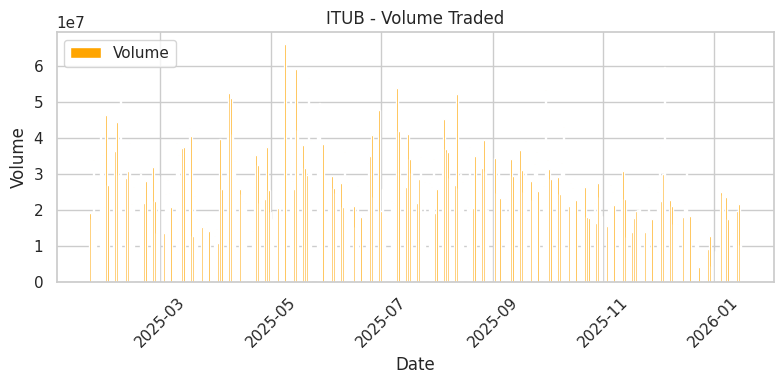

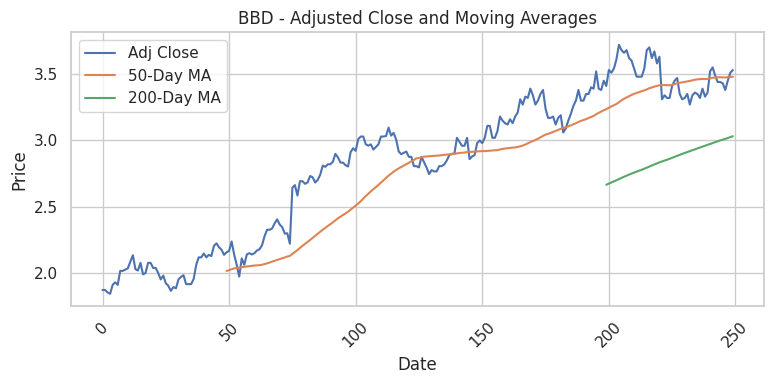

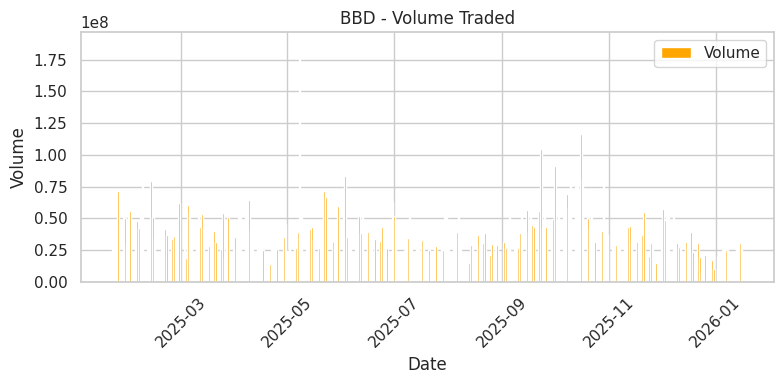

In [5]:
short_window = 50
long_window = 200

unique_tickers = stock_data['Ticker'].unique()

# plotting
for ticker in unique_tickers:
    ticker_data = stock_data[stock_data['Ticker'] == ticker].copy()
    ticker_data = ticker_data[~ticker_data.isnull()]
    ticker_data['50_MA'] = ticker_data['Close'].rolling(window=short_window).mean()
    ticker_data['200_MA'] = ticker_data['Close'].rolling(window=long_window).mean()

    ticker_data = ticker_data.reset_index()


    #formatting settings
    plt.figure(figsize=(8, 4))

    plt.plot(ticker_data.index,
             ticker_data['Close'],
             label='Adj Close')

    plt.plot(ticker_data.index,
             ticker_data['50_MA'],
             label='50-Day MA')

    plt.plot(ticker_data.index,
             ticker_data['200_MA'],
             label='200-Day MA')

    plt.title(f'{ticker} - Adjusted Close and Moving Averages')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.bar(ticker_data['Date'],
            ticker_data['Volume'],
            label='Volume',
            color='orange')

    plt.title(f'{ticker} - Volume Traded')
    plt.xlabel('Date')
    plt.ylabel('Volume')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### KDE of daily returns

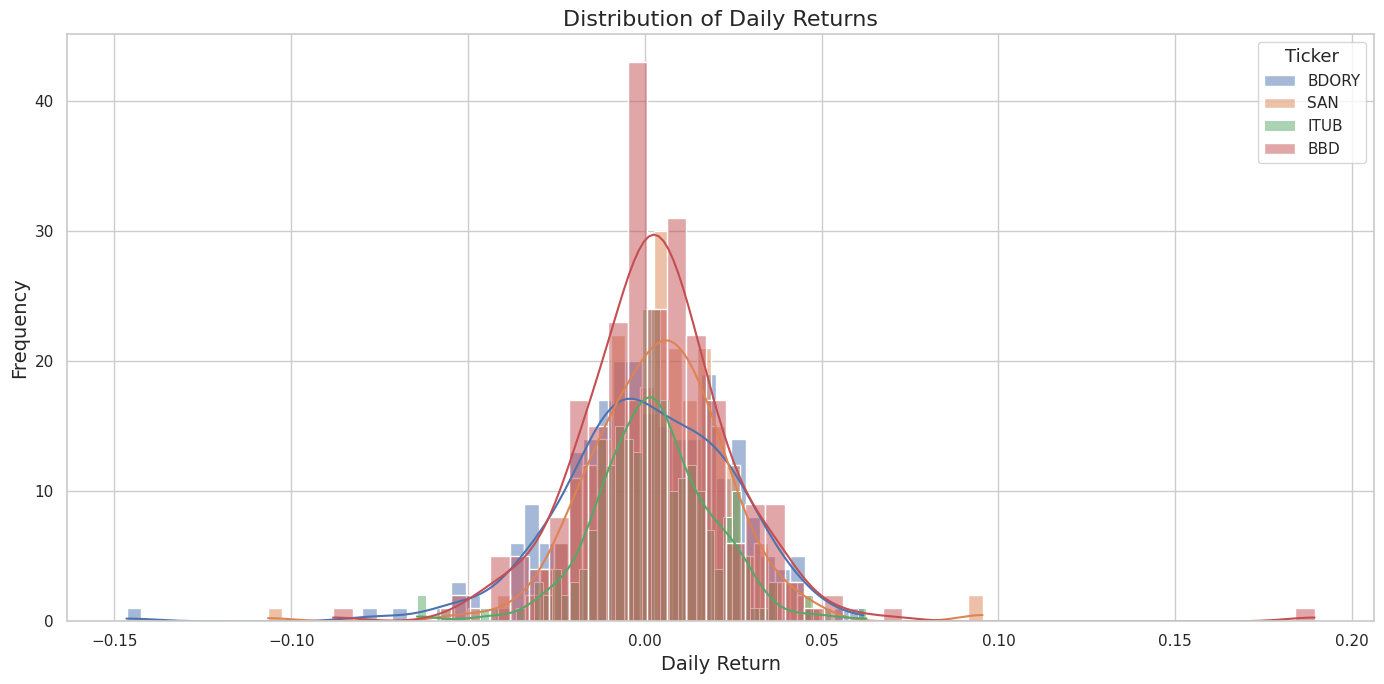

In [6]:
stock_data['Daily Return'] = (
    stock_data.groupby('Ticker')['Close']
    .pct_change()
    )

# plot setups
plt.figure(figsize=(14, 7))
sns.set(style='whitegrid')


# plotting
for ticker in unique_tickers:
    ticker_data = stock_data[stock_data['Ticker'] == ticker]
    sns.histplot(ticker_data['Daily Return'].dropna(), bins=50, kde=True, label=ticker, alpha=0.5)


# formatting settings
plt.title('Distribution of Daily Returns', fontsize=16)
plt.xlabel('Daily Return', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend(title='Ticker', title_fontsize='13', fontsize='11')
plt.grid(True)
plt.tight_layout()
plt.show()

## Return and Risk Modeling

#### Calculating correlation and Covariance

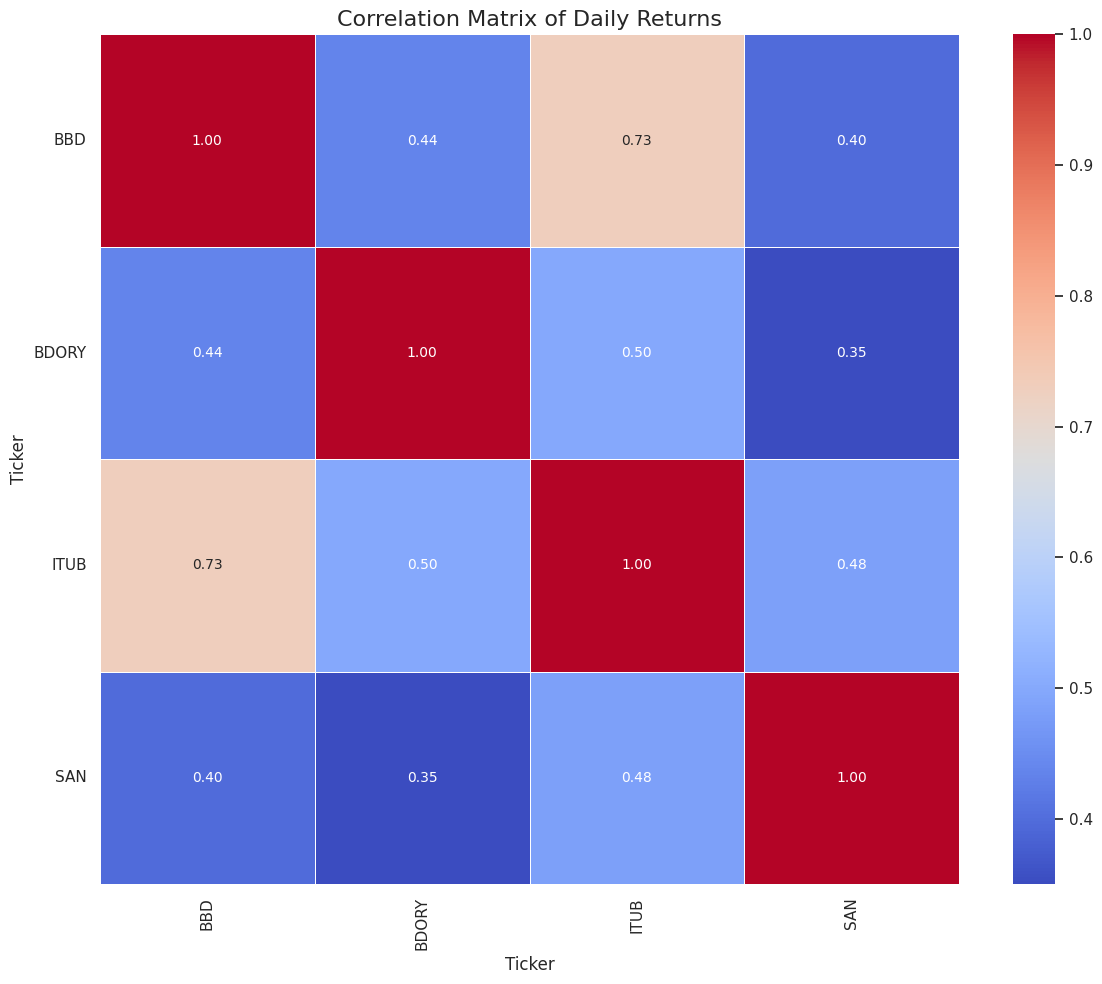

In [7]:
daily_returns = stock_data.pivot_table(
    index='Date',
    columns='Ticker',
    values='Daily Return'
    )
correlation_matrix = daily_returns.corr()

# plot setup
plt.figure(figsize=(12, 10))
sns.set(style='whitegrid')


# correlation matrix plotting + formatting settings
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=.5, fmt='.2f', annot_kws={"size": 10})
plt.title('Correlation Matrix of Daily Returns', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Calculating expected Return and Volatility

In [8]:
# annualizing the returns
expected_returns = daily_returns.mean() * 252
# annualizing the volatility
volatility = daily_returns.std() * np.sqrt(252)

stock_stats = pd.DataFrame(
    {
    'Expected Return': expected_returns,
    'Volatility': volatility
    }
  )

stock_stats

,Expected Return,Volatility
Ticker,,
BBD,0.708183,0.372438
BDORY,0.052081,0.391546
ITUB,0.605101,0.267793
SAN,0.987090,0.326076


#### Visualizing the "Efficiency Frontier" for maximum portfolio efficiency and securities allocation

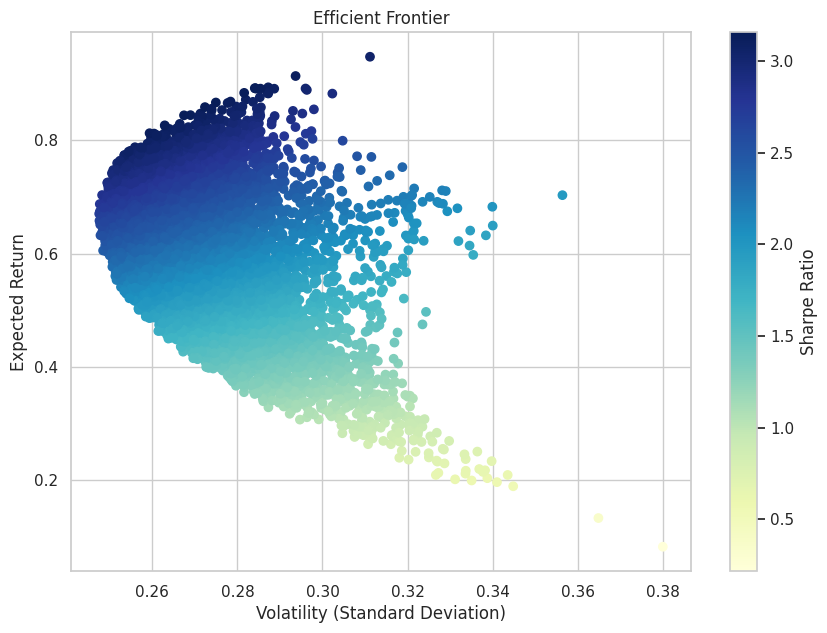

In [9]:
# custom function to calculate portfolio performance
def portfolio_performance(weights, returns, cov_matrix):
    portfolio_return = np.dot(weights, returns)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return portfolio_return, portfolio_volatility

# number of portfolios to simulate
num_portfolios = 10000

# we store the results in a variable
results = np.zeros((3, num_portfolios))

# calculating for the annualized covariance matrix
cov_matrix = daily_returns.cov() * 252
np.random.seed(42)


# plotting the performance frontier
for i in range(num_portfolios):
    weights = np.random.random(len(unique_tickers))
    weights /= np.sum(weights)

    portfolio_return, portfolio_volatility = portfolio_performance(weights, expected_returns, cov_matrix)

    results[0,i] = portfolio_return
    results[1,i] = portfolio_volatility
    results[2,i] = portfolio_return / portfolio_volatility  # This is the Sharpe Ratio


# plot settings
plt.figure(figsize=(10, 7))
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='YlGnBu', marker='o')
plt.title('Efficient Frontier')
plt.xlabel('Volatility (Standard Deviation)')
plt.ylabel('Expected Return')
plt.colorbar(label='Sharpe Ratio')
plt.grid(True)
plt.show()

#### Calculating the maximum values for Expected Return, Volatilty and Sharpe Ratio

In [17]:
max_sharpe_idx = np.argmax(results[2])
max_sharpe_return = results[0, max_sharpe_idx]
max_sharpe_volatility = results[1, max_sharpe_idx]
max_sharpe_ratio = results[2, max_sharpe_idx]

print(' Max Expected Return:   ',(max_sharpe_return * 100), '\n',
      'Max Volatility:        ', (max_sharpe_volatility * 100),'\n',
      'Max Sharpe Ratio:      ', max_sharpe_ratio)

 Max Expected Return:    84.4151270240998 
 Max Volatility:         26.744634154904162 
 Max Sharpe Ratio:       3.1563388205338603


#### Using the values calculated in the last cell to optimize the stock allocations within the porfolio

In [11]:
# sharpe ratio weight calculation
max_sharpe_weights = np.zeros(len(unique_tickers))

# exctracting the ratios weights
for i in range(num_portfolios):
    weights = np.random.random(len(unique_tickers))
    weights /= np.sum(weights)

    portfolio_return, portfolio_volatility = (portfolio_performance(
      weights,
      expected_returns,
      cov_matrix
      )
     )

    if results[2, i] == max_sharpe_ratio:
        max_sharpe_weights = weights * 100
        break

# dataframe creation for sharpe rateo weights
portfolio_weights_df = pd.DataFrame(
    {
    'Ticker': unique_tickers,
    'Weight': max_sharpe_weights
    }
  )

portfolio_weights_df

,Ticker,Weight
0,BDORY,32.089994
1,SAN,17.355145
2,ITUB,43.369278
3,BBD,7.185583
